# Project 2 Notebook (R): Estimation from a Random Sample  
**Question:** What is the mean age of high schools in California (in 2024)?

This notebook walks through the sample project step-by-step:
1. Enter your simple random sample of school ages  
2. Compute descriptive statistics (mean, SD)  
3. Make two plots (a basic version and a more colorful version)  
4. Compute a **95% confidence interval** for the population mean age **with a finite population correction (FPC)**  
5. Compute the interval a second way using a higher-level library (`survey`)


## Quick function summary (new functions used)

### Base R
- `mean(x)` — computes the sample mean  
- `sd(x)` — computes the sample standard deviation  
- `length(x)` — counts how many observations are in a vector (sample size \(n\))

### ggplot2 (plots)
- `geom_histogram(...)` — makes a histogram (binned bar chart of counts)  
- `geom_dotplot(...)` — stacks dots vertically for repeated values (duplicates) at the same x-value


## Step 0 — Install/load packages

We will use:
- **ggplot2** for plots  
- **survey** (later) for a “high-level” confidence interval calculation that can incorporate **finite population correction**


In [ ]:
# Install packages if needed (uncomment if you don't have them)
# install.packages("ggplot2")
install.packages("survey")

library(ggplot2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘minqa’, ‘numDeriv’, ‘mitools’, ‘RcppArmadillo’




## Step 1 — Enter your sample ages and the population size

**Population (N):** All CA high schools in the directory (example: `N = 1617`)  
**Sample (ages):** The ages (in years, in 2024) of your randomly selected schools.

### How to compute each age
If a school opened in year `open_year`, then  
\[
\text{age in 2024} = 2024 - \text{open\_year}.
\]

**Action:** Replace the `c()` below with your sample ages.


In [ ]:
# Your sample ages (in years, in 2024)
ages <- c(12, 58, 41, 5, 33, 19, 72, 28, 14, 73)

# Known population size from the directory
N <- 1617

# Quick check: sample size n
length(ages)


[1] 10

## Step 2 — Descriptive statistics

We compute:
- the **sample mean**: `mean(ages)`  
- the **sample standard deviation**: `sd(ages)`

These summarize the center and spread of your sample.


In [ ]:
mean(ages)
sd(ages)


[1] 35.5

[1] 24.84284

## Step 3 — Plot (Version 1): simple histogram with stacked dots

This plot does two things at once:
- A **histogram** shows how many schools fall into each age range (bins).
- A **dotplot overlay** shows the **actual observed ages**.
  - If there are duplicates (e.g., two schools with age 25), the dots stack vertically at that x-value.

### Notes
- `binwidth` controls the histogram bin size (in years).  
  - For a sample of 10, `binwidth = 10` is a reasonable start.  
- In `geom_dotplot`, set `binwidth = 1` to keep dots aligned to integer ages.


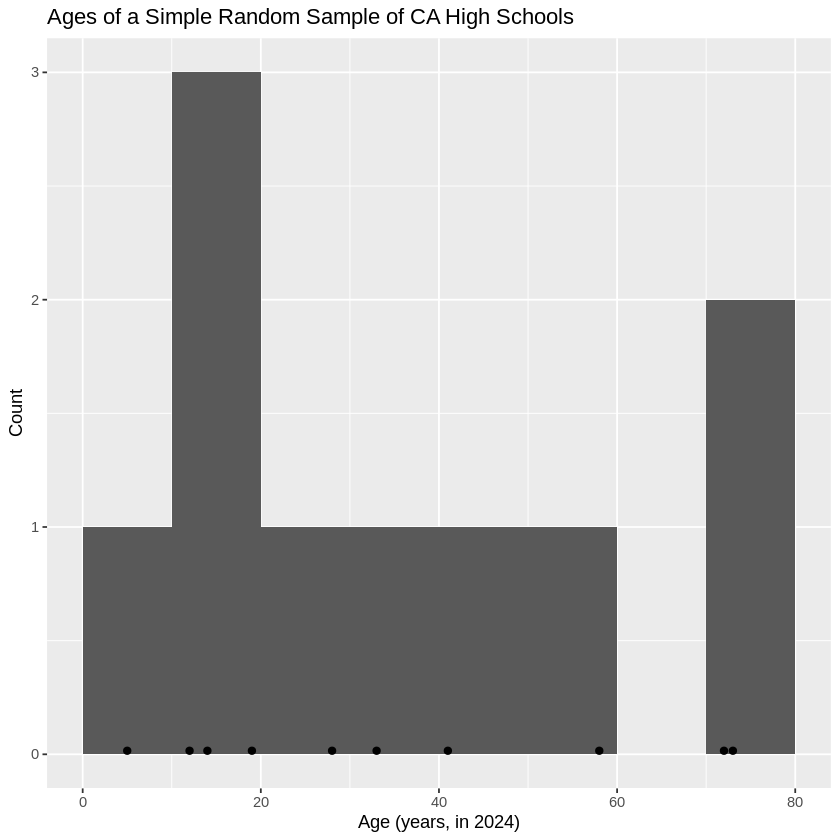

In [ ]:
ggplot(data.frame(ages = ages), aes(x = ages)) +
  geom_histogram(binwidth = 10, boundary = 0) +
  geom_dotplot(binwidth = 1,
               stackdir = "up",
               dotsize = 0.8) +
  labs(
    title = "Ages of a Simple Random Sample of CA High Schools",
    x = "Age (years, in 2024)",
    y = "Count"
  )


## Step 4 — Plot (Version 2): a more colorful version

This version adds:
- a filled histogram (`fill=...`) and bar outline (`color=...`)
- slightly different dot styling
- a minimal theme for a cleaner look

Feel free to edit colors to match your course style.


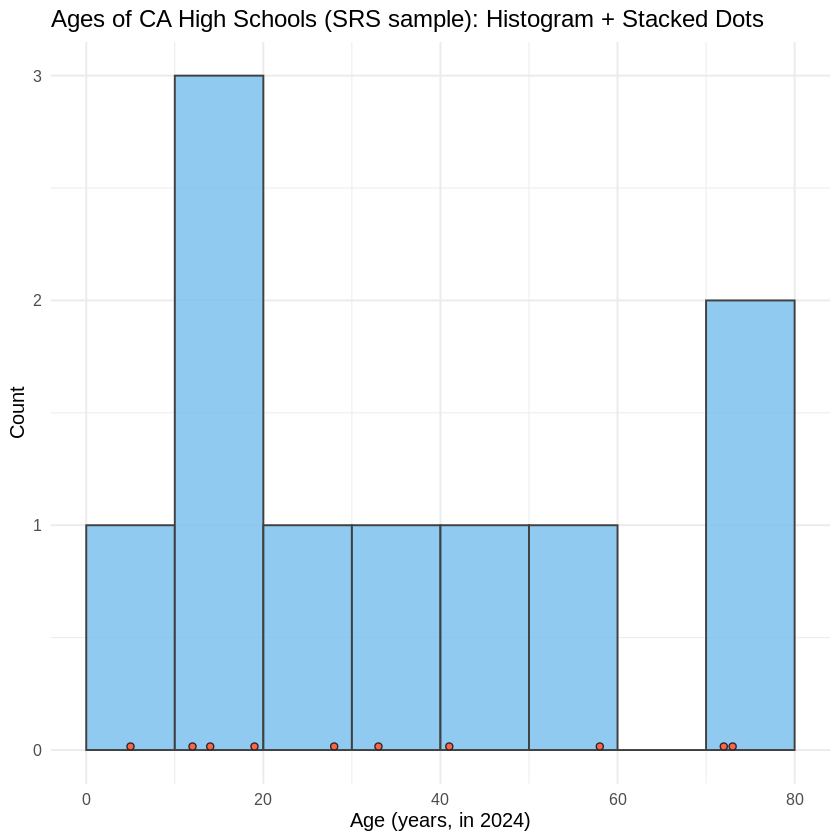

In [ ]:
ggplot(data.frame(ages = ages), aes(x = ages)) +
  geom_histogram(binwidth = 10, boundary = 0,
                 fill = "skyblue2", color = "gray25", alpha = 0.85) +
  geom_dotplot(binwidth = 1,
               stackdir = "up",
               dotsize = 0.8,
               fill = "tomato", color = "gray15") +
  theme_minimal(base_size = 12) +
  labs(
    title = "Ages of CA High Schools (SRS sample): Histogram + Stacked Dots",
    x = "Age (years, in 2024)",
    y = "Count"
  )


## Step 5 — 95% confidence interval for the mean (manual formula + FPC)

Because you sampled **without replacement** from a **finite** population of size \(N\), the standard error can be adjusted using the **finite population correction**:




In [ ]:
mean(ages) + c(-1, 1) * 2 *
  (sd(ages) / sqrt(length(ages))) *
  sqrt((N - length(ages)) / (N - 1))


[1] 19.83182 51.16818

## Step 6 — 95% confidence interval (high-level method) using the `survey` package

The **survey** package is designed for survey sampling and supports **finite population correction** through the design object.

### What we do
1. Put the data into a data frame  
2. Create a survey design representing an SRS without replacement  
3. Compute the mean and its standard error with `svymean()`  
4. Get a 95% CI with `confint()`

This provides a nice “library-based” alternative to the manual formula.


In [ ]:
library(survey)

df <- data.frame(ages = ages)

# For an SRS from a finite population, supply an fpc value.
# Here we use a constant N for each sampled unit.
df$fpc <- rep(N, nrow(df))

des <- svydesign(ids = ~1, data = df, fpc = ~fpc)

m <- svymean(~ages, des)
m
confint(m)   # 95% CI by default


Loading required package: grid

Loading required package: Matrix

Loading required package: survival


Attaching package: ‘survey’


The following object is masked from ‘package:graphics’:

    dotchart




     mean     SE
ages 35.5 7.8317

,2.5 %,97.5 %
ages,20.15022,50.84978


## Step 7 — One-sentence interpretation template (edit the numbers)

After you run the interval code, plug the endpoints into something like:

> “Based on this simple random sample of \(n\) CA high schools, I’m 95% confident that the true mean age of **all \(N\)** CA high schools (in 2024) is between **L** and **U** years.”

You can copy the CI endpoints directly from the output.
